How does molmo see the the image?

1. Loading the model

In [1]:
import torch
from transformers import AutoProcessor, AutoModelForImageTextToText

MODEL_NAME = "allenai/Molmo2-4B"
processor = AutoProcessor.from_pretrained(MODEL_NAME, trust_remote_code=True)
model = AutoModelForImageTextToText.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True,
    dtype=torch.float32,
    device_map="auto",
)
model.eval()

I0000 00:00:1779885510.624136 1214961 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779885511.456746 1214961 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779885512.991002 1214961 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=T

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Molmo2ForConditionalGeneration(
  (model): Molmo2Model(
    (transformer): Molmo2TextModel(
      (wte): Molmo2Embedding()
      (emb_drop): Dropout(p=0.0, inplace=False)
      (blocks): ModuleList(
        (0-35): 36 x Molmo2DecoderLayer(
          (self_attn): Molmo2Attention(
            (att_proj): Linear(in_features=2560, out_features=6144, bias=False)
            (k_norm): Molmo2RMSNorm((128,), eps=1e-06)
            (q_norm): Molmo2RMSNorm((128,), eps=1e-06)
            (attn_out): Linear(in_features=4096, out_features=2560, bias=False)
          )
          (attn_norm): Molmo2RMSNorm((2560,), eps=1e-06)
          (dropout): Dropout(p=0.0, inplace=False)
          (mlp): LanguageModelMLP(
            (ff_proj): Linear(in_features=2560, out_features=19456, bias=False)
            (ff_out): Linear(in_features=9728, out_features=2560, bias=False)
            (act): SiLUActivation()
          )
          (ff_norm): Molmo2RMSNorm((2560,), eps=1e-06)
        )
      )
      (ln_f): Mo

2. Loading data for testing

In [2]:
from heca.helper import molmo
images, _, ground_truths, task_names, letters_per_task = molmo.get_data()

4. Preproccessing the raw promots into molmo format

In [5]:
chat_texts = []
message = [
        {
            "role": "user",
            "content": [
                {"type": "image"},
                {"type": "text", "text": "Describe the image in exhaustive detail. List every visible object, its color, material, position, state, and spatial relation to other objects. Describe drawers, sliders, buttons, blocks, and containers carefully. Do not summarize briefly."},
            ],
        }
    ]
chat_text = processor.apply_chat_template(
        message,
        tokenize=False,
        add_generation_prompt=True,
)
 

In [ ]:
import random
import torch

rng = random.Random(42)

num_samples = 3
sample_idxs = sorted(rng.sample(range(len(images)), num_samples))

sample_images = [images[i] for i in sample_idxs]
sample_tasks = [task_names[i] for i in sample_idxs]
sample_gt = [ground_truths[i] for i in sample_idxs]

# -------------------------------------------------------------------
# 2) run exact processor path
# -------------------------------------------------------------------

sample_inputs = processor(
    images=sample_images,
    text=[chat_text] * num_samples,
    return_tensors="pt",
    padding=True,
)
sample_inputs.pop("token_type_ids", None)
with torch.inference_mode():
    outputs = model.generate(  # type: ignore
        **sample_inputs,
        do_sample=False,
        max_new_tokens=2048,
    )


The image depicts a computer-generated scene with a wooden workbench as the central focus. The workbench is positioned diagonally, with its left side closer to the viewer and its right side receding into the background. The surface of the workbench is light brown, and it has a darker brown border around its edges.

On the workbench, there are several objects:

1. A blue cube
2. A red cube
3. A pink cube
4. A green cube
5. A green ball

These objects are scattered across the workbench surface, creating a colorful and varied arrangement.

The workbench has a drawer with a gray handle. The drawer is partially open, revealing a gray interior. The handle is positioned on the front of the drawer, and it appears to be made of the same material as the rest of the workbench.

To the left of the workbench, there is a white robotic arm. The arm is positioned as if it's about to interact with the objects on the workbench. The robotic arm has a cylindrical body and two black claws at its end, which

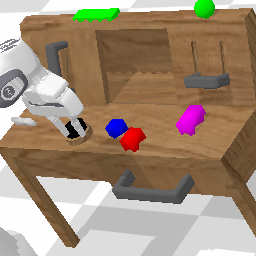

The image depicts a computer-generated scene with a wooden workbench as the central focus. The workbench is positioned diagonally, with its left side closer to the viewer and its right side receding into the background. The surface of the workbench is light brown, and it has a darker brown border around its edges.

On the workbench, there are several objects:

1. A blue cube
2. A red cube
3. A pink cube
4. A green cube
5. A green ball

These objects are scattered across the workbench surface, creating a colorful and varied arrangement.

The workbench has a drawer with a gray handle. The drawer is partially open, revealing a gray interior. The handle is positioned on the front of the drawer, and it appears to be made of the same material as the rest of the workbench.

To the left of the workbench, there is a white robotic arm. The arm is positioned as if it's about to interact with the objects on the workbench. The robotic arm has a cylindrical body and two black claws at its end, which

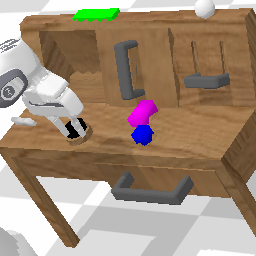

The image depicts a detailed 3D model of a wooden workbench with various objects arranged on and around it. Here's a comprehensive description of the visible elements:

1. Workbench:
- Material: Wood
- Color: Brown
- Position: Central focus of the image
- State: Appears to be in good condition

2. Drawer:
- Material: Wood
- Color: Brown
- Position: Located on the front of the workbench
- State: Closed
- Handle: Gray

3. Sliders:
- Material: Wood
- Color: Brown
- Position: Located on the back of the workbench
- State: Closed
- Handle: Gray

4. White ball:
- Material: Likely plastic or rubber
- Color: White
- Position: Located on the back of the workbench
- State: Appears to be intact

5. Green object:
- Material: Likely plastic or rubber
- Color: Green
- Position: Located on the back of the workbench
- State: Appears to be intact

6. Pink object:
- Material: Likely plastic or rubber
- Color: Pink
- Position: Located on the workbench surface
- State: Appears to be intact

7. Blue object:

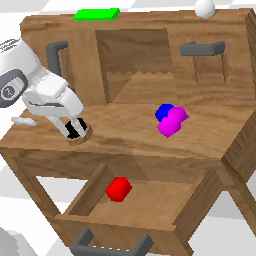

The image depicts a detailed 3D model of a wooden workbench with various objects and features. Here's a comprehensive breakdown of the visible elements:

1. Workbench:
- Material: Wood
- Color: Brown
- Position: Central focus of the image
- State: Open, with a drawer pulled out

2. Drawer:
- Material: Wood
- Color: Brown
- Position: Pulled out from the bottom of the workbench
- State: Open
- Contents: Contains a red cube

3. Sliders:
- Material: Wood
- Color: Brown
- Position: On the sides of the workbench
- State: Open
- Contents: Each slider contains a gray object

4. White object:
- Material: Not specified
- Color: White
- Position: On the left side of the workbench
- State: Appears to be a tool or instrument

5. Pink object:
- Material: Not specified
- Color: Pink
- Position: On the right side of the workbench
- State: Appears to be a tool or instrument

6. Blue object:
- Material: Not specified
- Color: Blue
- Position: On the right side of the workbench
- State: Appears to be a t

In [13]:
# only get generated tokens; decode them to text
generated_tokens = outputs[:, sample_inputs["input_ids"].size(1) :]
generated_text = processor.tokenizer.batch_decode(generated_tokens, skip_special_tokens=True)

# print the generated text
for i in range(num_samples):
     display(sample_images[i])
     print(f"{generated_text[i]}")
     print("-" * 50)
